# Linear Regression - Implementation

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [4]:
data = pd.read_csv("linear_data.csv")

In [5]:
data.head()

,problems_solved,contest_score
0,12,15
1,25,32
2,45,58
3,50,65
4,75,85


In [6]:
data.rename(columns={'problems_solved':'X', 'contest_score':'Y'}, inplace = True)

In [7]:
data['X'] = data['X'].astype(int)
data['Y'] = data['Y'].astype(float)

In [8]:
data['XY'] = data['X'] * data['Y']

In [9]:
data['XX'] = data['X'] * data['X']

In [10]:
data

,X,Y,XY,XX
0,12,15.0,180.0,144
1,25,32.0,800.0,625
2,45,58.0,2610.0,2025
3,50,65.0,3250.0,2500
4,75,85.0,6375.0,5625
5,82,90.0,7380.0,6724
6,95,98.0,9310.0,9025
7,5,10.0,50.0,25
8,30,40.0,1200.0,900
9,60,70.0,4200.0,3600


In [11]:
xAvg = sum(data['X']) / len(data)
print(xAvg)
xAvgSq = xAvg * xAvg
print(xAvgSq)

47.9
2294.41


In [12]:
yAvg = sum(data['Y']) / len(data)
yAvg

56.3

In [13]:
xyAvg = sum(data['XY']) / len(data)
xyAvg

3535.5

In [14]:
xxAvg = sum(data['XX']) / len(data)
xxAvg

3119.3

In [15]:
m = ((xAvg * yAvg) - xyAvg) / ((xAvgSq) - xxAvg)
m

1.0167779946417095

In [16]:
c = yAvg - (m * xAvg)
c

7.596334056662116

In [17]:
def f(x):
    return (m * x) + c

In [18]:
print(f(60))

68.6030137351647


In [19]:
print(f(62))

70.6365697244481


# Linear Regression - Built in

In [20]:
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
data = pd.read_csv('linear_data.csv')

In [22]:
data.head()

,problems_solved,contest_score
0,12,15
1,25,32
2,45,58
3,50,65
4,75,85


In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
X = np.array(data['problems_solved'])

In [25]:
print(X)

[12 25 45 50 75 82 95  5 30 60]


In [26]:
X = X.reshape(-1, 1)
X

array([[12],
       [25],
       [45],
       [50],
       [75],
       [82],
       [95],
       [ 5],
       [30],
       [60]])

In [27]:
y = np.array(data['contest_score'])
y

array([15, 32, 58, 65, 85, 90, 98, 10, 40, 70])

In [28]:
model = LinearRegression()

In [29]:
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
model.predict([[60]])

array([68.60301374])

In [31]:
model.predict([[62]])

array([70.63656972])

# Graph Representation

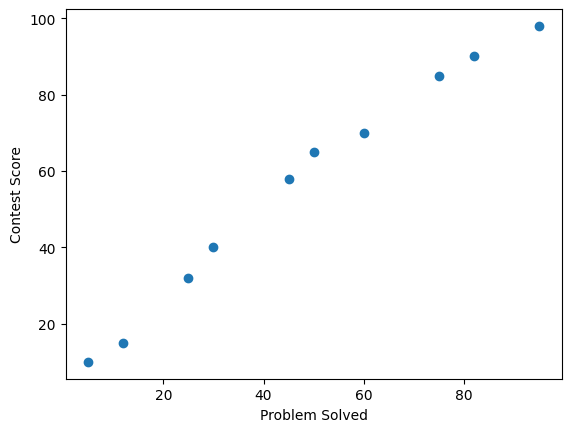

In [36]:
plt.xlabel('Problem Solved')
plt.ylabel('Contest Score')
plt.scatter(X, y)

In [40]:
testx = 58
texty_i = f(testx)
testy_b = model.predict([[testx]])
print(texty_i, testy_b)

66.56945774588127 [66.56945775]


In [39]:
testx = 62
texty_i = f(testx)
testy_b = model.predict([[testx]])
print(texty_i, testy_b)

70.6365697244481 [70.63656972]
